# Why a Reach-trained VID overlap does not transfer

This fully synthetic experiment isolates one failure mode: two campaign families have the same expected single-publisher reaches but draw from populations with different cross-publisher affinity. A model trained only on broad Reach campaigns therefore learns the wrong shared-population size for Traffic campaigns.

The experiment then tests whether a campaign-specific shared-fingerprint signal can adjust that shared population without changing either publisher's own reach.

## Experimental design

- Two publishers, named A and B.
- Two latent populations with equal marginal reach probabilities.
- The broad Reach population has higher person overlap than the response population used by Traffic campaigns.
- Ten Reach campaigns fit both models.
- Ten new Reach campaigns and ten Traffic campaigns are held out for evaluation.
- A fingerprint is available for 30% of publisher A's audience and 80% of publisher B's audience.
- When the same person has a fingerprint at both publishers, those fingerprints agree with 60% probability.
- The simulator retains the held-out true person overlap until evaluation.

The fixed model first learns the normal publisher overlap from Reach campaigns. The calibrated model retains that Reach baseline and adds one parameter, `reference_sensitivity`, which translates a campaign's coverage-corrected fingerprint-overlap deviation into a change in the shared virtual population.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from google.protobuf import text_format
from calibrated_vid.experiment import load_experiment, run_experiment

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
OUTPUT = ROOT / "outputs" / "two_population_experiment"
campaigns, predictions, model, summary = run_experiment(
    ROOT / "configs" / "two_population_experiment.textproto", OUTPUT
)
print(text_format.MessageToString(model.as_proto()))
summary

base_overlap_rate: 0.5027597684501801
reference_overlap_center: 0.5027597684501801
reference_sensitivity: 1.005049926592663



[{'objective': 'reach',
  'campaigns': 10,
  'fixed_overlap_mae_points': 6.822777274399025,
  'calibrated_overlap_mae_points': 0.7334396995284604,
  'fixed_union_mape_percent': 3.925987492487578,
  'calibrated_union_mape_percent': 0.43087226462309836},
 {'objective': 'traffic',
  'campaigns': 10,
  'fixed_overlap_mae_points': 30.480904616609088,
  'calibrated_overlap_mae_points': 0.3384818543763285,
  'fixed_union_mape_percent': 14.854020565643193,
  'calibrated_union_mape_percent': 0.16468100710481698}]

## The two latent populations

Both populations have expected reach of 40% on publisher A and 32% on publisher B. Only their probability of appearing on both publishers differs. Campaign size is therefore held constant while cross-publisher audience composition changes.

In [2]:
spec = load_experiment(ROOT / "configs" / "two_population_experiment.textproto")
population_rows = []
for population in spec.populations:
    rates = {group.publisher: group.reach_probability for group in population.event_groups}
    population_rows.append({
        "population": population.name,
        "publisher A expected reach": rates["publisher_a"],
        "publisher B expected reach": rates["publisher_b"],
        "expected overlap / smaller reach": population.overlap_rate_of_smaller_reach,
    })
population_rows

[{'population': 'broad_reach_population',
  'publisher A expected reach': 0.4,
  'publisher B expected reach': 0.32,
  'expected overlap / smaller reach': 0.55},
 {'population': 'response_population',
  'publisher A expected reach': 0.4,
  'publisher B expected reach': 0.32,
  'expected overlap / smaller reach': 0.22}]

## Fingerprint observation model

Fingerprint availability and fingerprint agreement are separate mechanisms. Let:

- $c_A=0.30$: fingerprint coverage among publisher A's reached audience
- $c_B=0.80$: fingerprint coverage among publisher B's reached audience
- $m=0.60$: agreement probability when the same person has fingerprints at both publishers

Assuming publisher coverage is independent within the true overlapping audience, the probability that a truly shared person becomes an observed fingerprint match is:

$$k = c_A c_B m = 0.30 \times 0.80 \times 0.60 = 0.144$$

Thus, 1,000 truly shared people produce 144 expected fingerprint matches. The raw match count is intentionally attenuated; it is not itself the person overlap.

In [3]:
fingerprint_model = spec.fingerprint_observation_model
observable_fraction = (
    fingerprint_model.publisher_a_coverage
    * fingerprint_model.publisher_b_coverage
    * fingerprint_model.conditional_match_probability
)
{
    "publisher A coverage": fingerprint_model.publisher_a_coverage,
    "publisher B coverage": fingerprint_model.publisher_b_coverage,
    "conditional agreement": fingerprint_model.conditional_match_probability,
    "observable fraction of true overlap": observable_fraction,
    "expected matches per 1,000 shared people": round(1000 * observable_fraction),
}

{'publisher A coverage': 0.3,
 'publisher B coverage': 0.8,
 'conditional agreement': 0.6,
 'observable fraction of true overlap': 0.144,
 'expected matches per 1,000 shared people': 144}

In [4]:
example = campaigns[0]
{
    "campaign": example.campaign_id,
    "publisher A reach": example.publisher_a_reach,
    "publisher A fingerprint reach": example.fingerprint_a_reach,
    "publisher A realized coverage": round(example.fingerprint_a_reach / example.publisher_a_reach, 3),
    "publisher B reach": example.publisher_b_reach,
    "publisher B fingerprint reach": example.fingerprint_b_reach,
    "publisher B realized coverage": round(example.fingerprint_b_reach / example.publisher_b_reach, 3),
    "true shared people": example.true_overlap,
    "observed fingerprint matches": example.fingerprint_matches,
    "observed fraction of true overlap": round(example.fingerprint_matches / example.true_overlap, 3),
    "matches / publisher A fingerprint reach": round(example.fingerprint_match_rate_from_a, 3),
    "matches / publisher B fingerprint reach": round(example.fingerprint_match_rate_from_b, 3),
    "true overlap rate": round(example.true_overlap_rate, 3),
    "coverage-corrected overlap rate": round(example.fingerprint_inferred_overlap_rate, 3),
}

{'campaign': 'reach-train-01',
 'publisher A reach': 80085,
 'publisher A fingerprint reach': 24210,
 'publisher A realized coverage': 0.302,
 'publisher B reach': 64182,
 'publisher B fingerprint reach': 51270,
 'publisher B realized coverage': 0.799,
 'true shared people': 36493,
 'observed fingerprint matches': 5274,
 'observed fraction of true overlap': 0.145,
 'matches / publisher A fingerprint reach': np.float64(0.218),
 'matches / publisher B fingerprint reach': np.float64(0.103),
 'true overlap rate': np.float64(0.569),
 'coverage-corrected overlap rate': np.float64(0.571)}

## Directional raw match rates

The same match count looks different from each publisher's fingerprint-covered audience. In expectation:

$$\frac{M}{c_A R_A} = \frac{O}{R_A}c_Bm = 0.48\frac{O}{R_A}$$

$$\frac{M}{c_B R_B} = \frac{O}{R_B}c_Am = 0.18\frac{O}{R_B}$$

The raw directional rates therefore cannot be compared directly. The correction below uses both publisher coverages and the conditional agreement probability.

## Two virtual-population allocations

For a campaign, let $R_A$ and $R_B$ be the publisher reaches, $S=\min(R_A,R_B)$, $O$ be the true overlap, and $M$ be the observed fingerprint matches. The Reach training campaigns establish the normal overlap rate:

$$q_R = \operatorname{mean}_{i \in \text{Reach train}} \left(\frac{O_i}{S_i}\right)$$

The measurement mechanism converts the campaign's match count back to a coverage-corrected reference estimate:

$$q_{FP} = \frac{M}{c_A c_B m S} = \frac{M}{0.144S}$$

The fixed model always uses $q_R$. The calibrated model adjusts that Reach baseline toward the campaign-specific reference estimate:

$$\hat q = q_R + \beta(q_{FP}-q_R)$$

The sensitivity $\beta$ is fitted using only the ten Reach training campaigns. No Traffic labels enter the fit.

For every campaign, both approaches preserve the observed publisher A and publisher B reaches. They differ only in how much of the smaller publisher audience is assigned to the shared virtual population:

```text
shared population = estimated overlap rate × S
publisher A only  = publisher A reach − shared population
publisher B only  = publisher B reach − shared population
union reach       = publisher A only + publisher B only + shared population
```

## What the correction observes

The observed match count is divided by its known 14.4% observation probability. Fingerprint availability and agreement are independent of campaign exposure in this controlled example, so the corrected rate is a noisy but unbiased campaign-specific view of the full overlap rate.

The chart deliberately includes held-out campaigns only as evaluation points. Their true overlap was not used to fit either model.

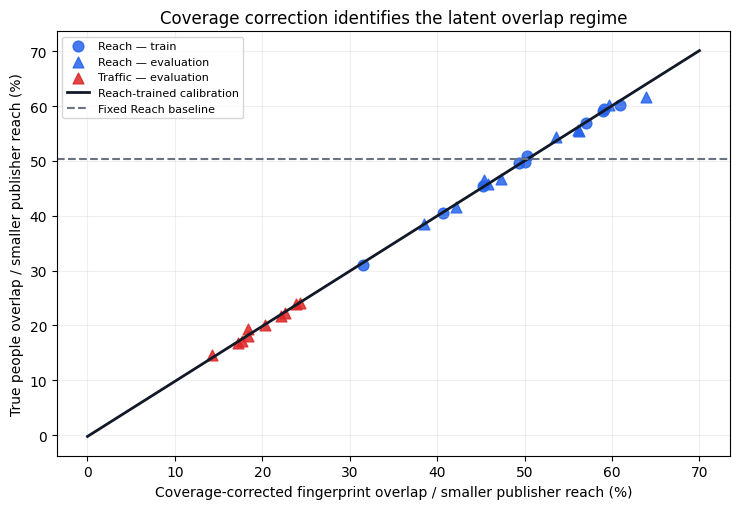

In [5]:
colors = {"reach": "#2563eb", "traffic": "#dc2626"}
markers = {"train": "o", "evaluation": "^"}
fig, ax = plt.subplots(figsize=(7.5, 5.2))
for objective in ["reach", "traffic"]:
    for split in ["train", "evaluation"]:
        rows = [c for c in campaigns if c.objective == objective and c.split == split]
        if not rows:
            continue
        ax.scatter(
            [100 * c.fingerprint_inferred_overlap_rate for c in rows],
            [100 * c.true_overlap_rate for c in rows],
            color=colors[objective],
            marker=markers[split],
            s=60,
            alpha=0.85,
            label=f"{objective.title()} — {split}",
        )
xx = np.linspace(0, 70, 200)
yy = 100 * (
    model.fixed_overlap_rate
    + model.reference_sensitivity * (xx / 100 - model.reference_overlap_center)
)
ax.plot(xx, yy, color="#111827", linewidth=2, label="Reach-trained calibration")
ax.axhline(
    100 * model.fixed_overlap_rate,
    color="#6b7280",
    linestyle="--",
    label="Fixed Reach baseline",
)
ax.set(
    xlabel="Coverage-corrected fingerprint overlap / smaller publisher reach (%)",
    ylabel="True people overlap / smaller publisher reach (%)",
    title="Coverage correction identifies the latent overlap regime",
)
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / "fingerprint_vs_true_overlap.png", dpi=180)
plt.show()

## Held-out performance

The critical comparison is Traffic, because no Traffic campaign was used during fitting. A fixed Reach overlap should systematically miss that population. A fingerprint-aware model trained on the same ten Reach campaigns can adapt when the campaign's corrected match signal exposes the shift.

The measurement consequence is unique reach. Total cross-publisher unique reach is:

$$U=R_A+R_B-O$$

If the Reach baseline overstates $O$, it subtracts too much and understates $U$. The incremental unique reach supplied by the smaller publisher is:

$$I=S-O$$

The chart reports signed error in the smaller publisher's incremental unique reach. Negative values mean that the model understates how many additional people the smaller publisher contributes. The following table separately reports the effect on total cross-publisher unique reach.

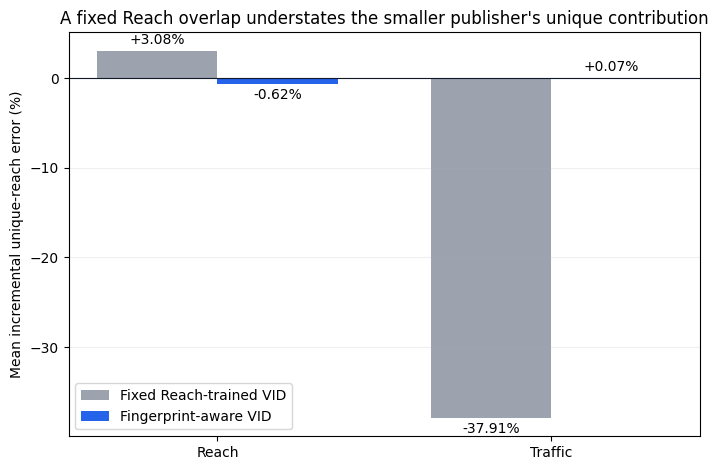

[{'objective': 'reach',
  'campaigns': 10,
  'fixed_overlap_mae_points': 6.822777274399025,
  'calibrated_overlap_mae_points': 0.7334396995284604,
  'fixed_union_mape_percent': 3.925987492487578,
  'calibrated_union_mape_percent': 0.43087226462309836},
 {'objective': 'traffic',
  'campaigns': 10,
  'fixed_overlap_mae_points': 30.480904616609088,
  'calibrated_overlap_mae_points': 0.3384818543763285,
  'fixed_union_mape_percent': 14.854020565643193,
  'calibrated_union_mape_percent': 0.16468100710481698}]

In [6]:
evaluation = [p for p in predictions if p.split == "evaluation"]
campaign_by_id = {campaign.campaign_id: campaign for campaign in campaigns}
objectives = ["reach", "traffic"]
fixed = []
calibrated = []
for objective in objectives:
    rows = [p for p in evaluation if p.objective == objective]
    fixed_errors = []
    calibrated_errors = []
    for prediction in rows:
        campaign = campaign_by_id[prediction.campaign_id]
        smaller_reach = min(campaign.publisher_a_reach, campaign.publisher_b_reach)
        true_incremental = smaller_reach - campaign.true_overlap
        fixed_incremental = smaller_reach * (1.0 - prediction.fixed_overlap_rate)
        calibrated_incremental = smaller_reach * (1.0 - prediction.calibrated_overlap_rate)
        fixed_errors.append(100 * (fixed_incremental - true_incremental) / true_incremental)
        calibrated_errors.append(
            100 * (calibrated_incremental - true_incremental) / true_incremental
        )
    fixed.append(np.mean(fixed_errors))
    calibrated.append(np.mean(calibrated_errors))

x = np.arange(len(objectives))
width = 0.36
fig, ax = plt.subplots(figsize=(7.2, 4.8))
fixed_bars = ax.bar(
    x - width / 2,
    fixed,
    width,
    label="Fixed Reach-trained VID",
    color="#9ca3af",
)
calibrated_bars = ax.bar(
    x + width / 2,
    calibrated,
    width,
    label="Fingerprint-aware VID",
    color="#2563eb",
)
ax.bar_label(fixed_bars, fmt="%+.2f%%", padding=3)
ax.bar_label(calibrated_bars, fmt="%+.2f%%", padding=3)
ax.set_xticks(x, [name.title() for name in objectives])
ax.set_ylabel("Mean incremental unique-reach error (%)")
ax.set_title("A fixed Reach overlap understates the smaller publisher's unique contribution")
ax.axhline(0, color="#111827", linewidth=0.8)
ax.grid(axis="y", alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "heldout_union_error.png", dpi=180)
plt.show()
summary

In [7]:
evaluation_rows = []
for objective in objectives:
    rows = [p for p in evaluation if p.objective == objective]
    campaign_rows = [campaign_by_id[p.campaign_id] for p in rows]
    fixed_overlap_relative_errors = []
    fixed_incremental_relative_errors = []
    calibrated_incremental_relative_errors = []
    for campaign, prediction in zip(campaign_rows, rows):
        smaller_reach = min(campaign.publisher_a_reach, campaign.publisher_b_reach)
        fixed_overlap = prediction.fixed_overlap_rate * smaller_reach
        calibrated_overlap = prediction.calibrated_overlap_rate * smaller_reach
        true_incremental = smaller_reach - campaign.true_overlap
        fixed_incremental = smaller_reach - fixed_overlap
        calibrated_incremental = smaller_reach - calibrated_overlap
        fixed_overlap_relative_errors.append(
            100 * (fixed_overlap - campaign.true_overlap) / campaign.true_overlap
        )
        fixed_incremental_relative_errors.append(
            100 * (fixed_incremental - true_incremental) / true_incremental
        )
        calibrated_incremental_relative_errors.append(
            100 * (calibrated_incremental - true_incremental) / true_incremental
        )
    evaluation_rows.append({
        "held-out objective": objective,
        "campaigns": len(rows),
        "fixed overlap MAE (points)": round(np.mean([abs(p.fixed_overlap_error_points) for p in rows]), 2),
        "fixed overlap relative error (%)": round(np.mean(fixed_overlap_relative_errors), 2),
        "fixed incremental unique-reach error (%)": round(np.mean(fixed_incremental_relative_errors), 2),
        "calibrated incremental unique-reach error (%)": round(np.mean(calibrated_incremental_relative_errors), 2),
        "fixed total unique-reach error (%)": round(np.mean([p.fixed_union_error_percent for p in rows]), 2),
        "calibrated total unique-reach error (%)": round(np.mean([p.calibrated_union_error_percent for p in rows]), 2),
    })
evaluation_rows

[{'held-out objective': 'reach',
  'campaigns': 10,
  'fixed overlap MAE (points)': np.float64(6.82),
  'fixed overlap relative error (%)': np.float64(1.61),
  'fixed incremental unique-reach error (%)': np.float64(3.08),
  'calibrated incremental unique-reach error (%)': np.float64(-0.62),
  'fixed total unique-reach error (%)': np.float64(0.39),
  'calibrated total unique-reach error (%)': np.float64(-0.15)},
 {'held-out objective': 'traffic',
  'campaigns': 10,
  'fixed overlap MAE (points)': np.float64(30.48),
  'fixed overlap relative error (%)': np.float64(160.38),
  'fixed incremental unique-reach error (%)': np.float64(-37.91),
  'calibrated incremental unique-reach error (%)': np.float64(0.07),
  'fixed total unique-reach error (%)': np.float64(-14.85),
  'calibrated total unique-reach error (%)': np.float64(0.03)}]

## Interpretation

The fixed model is not wrong because a campaign is named Traffic. It is wrong because those campaigns draw from a population with different cross-publisher affinity. Objective is merely an observable proxy for that latent population.

The Reach baseline supplies the normal publisher overlap. The corrected fingerprint signal supplies campaign-specific evidence about departures from that baseline. It changes only estimated overlap, leaving both single-publisher reaches untouched. In this controlled experiment it removes most of the held-out Traffic error despite never fitting on Traffic.

For the held-out Traffic campaigns, the fixed Reach baseline overstates overlap by roughly 160% relative to actual overlap. That causes it to understate the smaller publisher's incremental unique reach by roughly 38% and total cross-publisher unique reach by roughly 15%. The calibrated model reduces the total unique-reach error to well below 1% in this synthetic setting.

This does **not** establish that fingerprint-bearing people represent people without a shared fingerprint in real data, nor that coverage and agreement are independent. Those assumptions require independent panel validation. The notebook establishes the mechanism, the identifiability requirement, and a held-out evaluation design.